<a href="https://colab.research.google.com/github/ThandoZwane06/Cisco-Data-Science-Essentials/blob/main/Lessons%20/%20Week_5_Lessons%20/%20blood_pressure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Pressure

Does blood pressure increase with age?

The `blood-pressure-usa.csv` file contains systolic blood pressure readings from 100 individuals sampled by the National Health and Nutrition Examination Survey (NHANES) in the U.S., with each person measured three times.

The `blood-pressure-yanomami.csv` file features systolic blood pressure data from 71 individuals of the Yanomami Tribe, who live in near-total isolation in the Amazon.

While the average American consumes about 3,500 mg of sodium daily (from salt), the Yanomami's intake is estimated to be less than 100 mg.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'blood-pressure-usa.csv', 'blood-pressure-yanomami.csv', and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving blood-pressure-usa.csv to blood-pressure-usa.csv
Saving blood-pressure-yanomami.csv to blood-pressure-yanomami.csv
Saving linear_model.py to linear_model.py


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('blood-pressure-usa.csv')
df.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [3]:
df_remote = pd.read_csv('blood-pressure-yanomami.csv')
df_remote.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107




#### Confounding Variables

The Yanomami people participated in the INTERSALT study, which examined 10,000 individiuals across 52 populations in 32 countries, examining the link between salt consumption and systolic blood pressure.

Does our data prove that salt intake causes the blood pressure differences between the US and Yanomami populations? What other confounding factors might exist?

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

class LinearModel:
  def __init__(self, model_name=""):
        self.model_name = model_name

  def fit(self, x, y):
        x = pd.DataFrame(x)
        linear_model = LinearRegression().fit(x, y)
        y_pred = linear_model.predict(x)
        self.slope = linear_model.coef_[0]
        self.intercept = linear_model.intercept_
        self.rsquared = r2_score(y, y_pred)

  def predict(self, x):
        return self.slope * x + self.intercept

  def plot_model(self, x_min, x_max, color="black"):
        y_min = self.predict(x_min)
        y_max = self.predict(x_max)
        plt.plot([x_min, x_max], [y_min, y_max], color=color)

  def print_model_info(self):
        m = self.slope
        b = self.intercept
        rsquared = self.rsquared
        model_name = self.model_name
        print(f'LinearModel({model_name}):')
        print(f'Parameters: slope = {m:.2f}, intercept = {b:.2f}')
        print(f'Equation: y = {m:.2f}x + {b:.2f}')
        print(f'Goodness of Fit (R²): {rsquared:.3f}')

In [12]:
#Calculate the average blood pressure for each of the participates of the US dataset
df["bp_avg"] = (df.eval('bp1+bp2+bp3')/3).round(0)
df.head()

,age,bp1,bp2,bp3,bp_avg
0,46,122,129,122,124.0
1,43,113,116,111,113.0
2,29,102,107,105,105.0
3,12,100,102,102,101.0
4,9,112,138,94,115.0


In [42]:
#lets create a model for the US dataset and fit the model to the data
US_model = LinearModel("US_Dataset")
US_model.fit(x=df["age"], y=df["bp_avg"])


In [41]:
#lets create a model for the Yanomami and fit the model to the data
Yanomami_model = LinearModel("Yanomami_Dataset")
Yanomami_model.fit(x=df_remote["age"], y=df_remote["bp"])


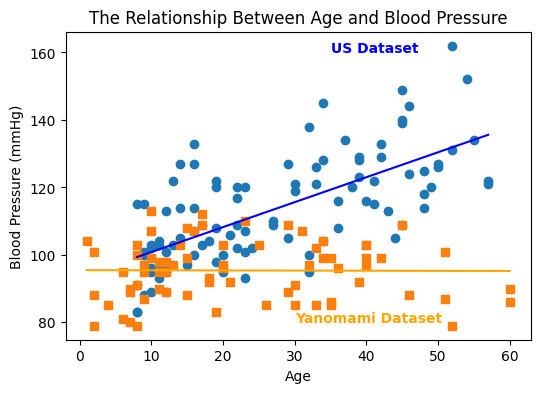

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
#US dataset scatterplot
plt.scatter(df['age'], df['bp_avg'], marker='o')
#Yanomami dataset
plt.scatter(df_remote['age'], df_remote['bp'], marker='s')

plt.xlabel('Age')
plt.ylabel('Blood Pressure (mmHg)')
plt.title('The Relationship Between Age and Blood Pressure')

#texts for the datasets, to make it easier to identify them
plt.text(x=35,y=160,s='US Dataset', color='blue', fontweight='bold')
plt.text(x=30,y=80,s='Yanomami Dataset', color='orange', fontweight='bold')

US_model.plot_model(x_min=df['age'].min(), x_max=df['age'].max(), color='blue')
Yanomami_model.plot_model(x_min=df_remote['age'].min(), x_max=df_remote['age'].max(), color='orange')

In [44]:
#model parameters for the US dataset
US_model.print_model_info()

LinearModel(US_Dataset):
Parameters: slope = 0.74, intercept = 93.44
Equation: y = 0.74x + 93.44
Goodness of Fit (R²): 0.470


The linear model reveals a moderate positive relationship between age and blood pressure (R^2 = 0.470)

In [45]:
#model parameters for the Yanomami dataset
Yanomami_model.print_model_info()

LinearModel(Yanomami_Dataset):
Parameters: slope = -0.00, intercept = 95.47
Equation: y = -0.00x + 95.47
Goodness of Fit (R²): 0.000


The linear model reveals no relationship between age and blood pressure in the Yanomami dataset

This data alone does not prove that salt intake causes the blood pressure difference. Comparing the US to the Yanomami introduces too many confounding variables. The Yanomami lifestyle lacks the processed sugars, alcohol, high obesity rates, sedentary habits, and chronic psychological stress common in industrialized Western societies. They also consume far more potassium, which naturally lowers blood pressure. Therefore, while low salt consumption is highly influential, their flatline blood pressure is caused by a combination of these healthy lifestyle factors, not just sodium restriction alone.